In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

In [2]:
tickers = [
    "FPT.VN",
    "HPG.VN",
    "VCB.VN",
    "TCB.VN",
    "MWG.VN"
]

base_folder = 'D:\StockPrice\data'
vn5_data = pd.read_excel(r'D:\StockPrice\data\VN5_Close_Volume.xlsx')


<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_15468\2852358051.py:9: SyntaxWarning: invalid escape sequence '\S'
  base_folder = 'D:\StockPrice\data'


In [3]:
vn5_data

,Date,FPT_Close,FPT_Volume,HPG_Close,HPG_Volume,VCB_Close,VCB_Volume,TCB_Close,TCB_Volume,MWG_Close,MWG_Volume
0,2019-01-01,13053.306641,0,7274.739258,0,34487.136719,0.0,24480.181641,0.0,25387.888672,0.0
1,2019-01-02,12743.988281,1218959,7239.482910,16681133,34551.597656,1629983.0,24057.296875,1329030.0,25123.429688,1055190.0
2,2019-01-03,12620.260742,1902566,6933.920410,27340066,34551.597656,1614477.0,23493.455078,1811430.0,24388.828125,2109180.0
3,2019-01-04,12713.056641,845800,6980.929199,23220796,35067.292969,1970058.0,23446.468750,2970830.0,24565.130859,1296510.0
4,2019-01-07,12929.579102,1084484,6898.662598,9894167,35196.214844,1771893.0,23587.429688,1436930.0,24976.513672,1194000.0
...,...,...,...,...,...,...,...,...,...,...,...
1925,2026-05-25,72501.359375,10441000,24100.000000,26989100,63700.000000,5410300.0,32550.000000,6800800.0,78700.000000,2510300.0
1926,2026-05-26,73487.773438,5104800,24250.000000,20723700,64400.000000,5623900.0,32900.000000,5439700.0,78500.000000,2518800.0
1927,2026-05-27,72600.000000,9176300,24150.000000,23114500,64200.000000,4185600.0,33650.000000,16305800.0,80000.000000,4631100.0
1928,2026-05-28,71200.000000,10646900,24000.000000,15668300,62800.000000,4972400.0,32600.000000,8065900.0,77700.000000,4026400.0


In [4]:
from vnstock import Vnstock

stock = Vnstock()
vnindex = stock.stock(symbol="VNINDEX", source="VCI")

data = vnindex.quote.history(
    start='2019-01-01',
    end='2026-06-01'
)

data = data[['time', 'close', 'volume']]
data = data.rename(columns={'time':'Date', 'close':'VNINDEX_Close', 'volume':'VNINDEX_Volume'})
data.to_excel(r'D:\StockPrice\data\VNINDEX.xlsx', engine='openpyxl', index=False)

2026-06-16 12:57:27 - vnstock.common.data - INFO - Not a stock. Company and finance data unavailable.



  ╭──────────────────────────────────────────────────────────╮
  │  ⚠️  VNSTOCK DEPRECATION NOTICE (31/08/2025)             │
  │                                                          │
  │  Lớp Vnstock và các phương thức cũ (stock, fx, crypto,   │
  │  world_index, fund...) đã chính thức bị ngừng hỗ trợ.    │
  │                                                          │
  │  Để hệ thống ổn định và nhận được cập nhật mới nhất,     │
  │  vui lòng chuyển sang dùng bộ thư viện `vnstock.api`.    │
  │                                                          │
  │  👉 Xem hướng dẫn Migration: /vnstock-migration          │
  ╰──────────────────────────────────────────────────────────╯

Mẫu code chuyển đổi (Migration Example):
--------------------------------------
Cũ (Old):  stock = Vnstock().stock('ACB')
Mới (New): from vnstock.api.quote import Quote
          q = Quote(symbol='ACB', source='VCI')



In [5]:
vn5_data['Date'].equals(data['Date'])

False

In [7]:
missing_in_df2 = vn5_data[~vn5_data['Date'].isin(data['Date'])]
missing_in_df2.to_csv('missing_date.csv')

In [8]:
merge_data = pd.merge(vn5_data, data, on='Date', how='left')
merge_data

,Date,FPT_Close,FPT_Volume,HPG_Close,HPG_Volume,VCB_Close,VCB_Volume,TCB_Close,TCB_Volume,MWG_Close,MWG_Volume,VNINDEX_Close,VNINDEX_Volume
0,2019-01-01,13053.306641,0,7274.739258,0,34487.136719,0.0,24480.181641,0.0,25387.888672,0.0,NaN,NaN
1,2019-01-02,12743.988281,1218959,7239.482910,16681133,34551.597656,1629983.0,24057.296875,1329030.0,25123.429688,1055190.0,891.75,91857070.0
2,2019-01-03,12620.260742,1902566,6933.920410,27340066,34551.597656,1614477.0,23493.455078,1811430.0,24388.828125,2109180.0,878.22,135125060.0
3,2019-01-04,12713.056641,845800,6980.929199,23220796,35067.292969,1970058.0,23446.468750,2970830.0,24565.130859,1296510.0,880.90,117664070.0
4,2019-01-07,12929.579102,1084484,6898.662598,9894167,35196.214844,1771893.0,23587.429688,1436930.0,24976.513672,1194000.0,889.64,87417130.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1925,2026-05-25,72501.359375,10441000,24100.000000,26989100,63700.000000,5410300.0,32550.000000,6800800.0,78700.000000,2510300.0,1886.03,702575224.0
1926,2026-05-26,73487.773438,5104800,24250.000000,20723700,64400.000000,5623900.0,32900.000000,5439700.0,78500.000000,2518800.0,1884.18,729758151.0
1927,2026-05-27,72600.000000,9176300,24150.000000,23114500,64200.000000,4185600.0,33650.000000,16305800.0,80000.000000,4631100.0,1874.43,830501943.0
1928,2026-05-28,71200.000000,10646900,24000.000000,15668300,62800.000000,4972400.0,32600.000000,8065900.0,77700.000000,4026400.0,1863.67,686200721.0


<Figure size 1200x600 with 0 Axes>

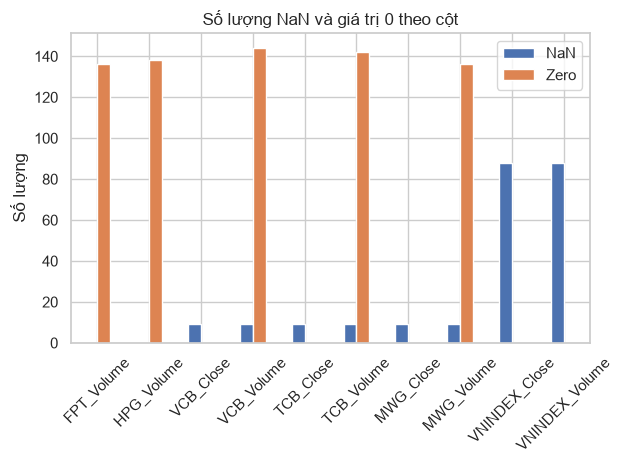

In [9]:
summary = pd.DataFrame({
    'NaN': merge_data.isna().sum(),
    'Zero': (merge_data == 0).sum()
})

# Chỉ giữ các cột có NaN hoặc Zero
summary = summary[(summary['NaN'] > 0) | (summary['Zero'] > 0)]

plt.figure(figsize=(12, 6))
summary.plot(kind='bar')
plt.title('Số lượng NaN và giá trị 0 theo cột')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
import holidays

vn_holidays = holidays.VN(years=range(2019, 2026))
org_data = merge_data

org_data['IsHoliday'] = org_data['Date'].apply(
    lambda x: 1 if x.date() in vn_holidays else 0
)
org_data['IsHoliday'] = org_data['IsHoliday'].astype(int)

org_data['DayOfWeek'] = org_data['Date'].dt.dayofweek + 2

org_data['DowSin'] = np.sin(2 * np.pi * org_data['DayOfWeek'] / 7)
org_data['DowCos'] = np.cos(2 * np.pi * org_data['DayOfWeek'] / 7)

org_data['Holiday_Window'] = 0

holiday_dates = pd.to_datetime(list(vn_holidays.keys()))

for holiday in holiday_dates:
    for i in range(-3, 4):
        mask = (org_data['Date'].dt.date == (holiday + pd.Timedelta(days=i)).date())
        org_data.loc[mask, 'Holiday_Window'] = i
        
org_data['Days_To_Holiday'] = org_data['Date'].apply(
    lambda x: min(abs((holiday_dates - x).days))
)

In [22]:
org_data.to_excel(r'D:\StockPrice\data\raw_data.xlsx', index=False, engine='openpyxl')

In [14]:
# Đánh dấu ngày lễ ở Việt Nam
merge_data['IsHoliday'] = (
    merge_data['Date'].dt.date
    .isin(vn_holidays.keys())
)

nan_rows = merge_data[
    merge_data.isna().any(axis=1)
]

price_volume_cols = [
    col for col in merge_data.columns
    if col.endswith('_Close') or col.endswith('_Volume')
]

zero_rows = merge_data[
    (merge_data[price_volume_cols] == 0)
    .any(axis=1)
]

print("Tổng số dòng có NaN:", len(nan_rows))
print("Trong đó là ngày lễ:", nan_rows['IsHoliday'].sum())

print("Tổng số dòng có giá trị 0:", len(zero_rows))
print("Trong đó là ngày lễ:", zero_rows['IsHoliday'].sum())

Tổng số dòng có NaN: 88
Trong đó là ngày lễ: 86
Tổng số dòng có giá trị 0: 160
Trong đó là ngày lễ: 86


In [16]:
org_data

,Date,FPT_Close,FPT_Volume,HPG_Close,HPG_Volume,VCB_Close,VCB_Volume,TCB_Close,TCB_Volume,MWG_Close,MWG_Volume,VNINDEX_Close,VNINDEX_Volume,IsHoliday,DayOfWeek,DowSin,DowCos,Holiday_Window,Days_To_Holiday
0,2019-01-01,13053.306641,0,7274.739258,0,34487.136719,0.0,24480.181641,0.0,25387.888672,0.0,NaN,NaN,True,1,0.781831,0.623490,0,0
1,2019-01-02,12743.988281,1218959,7239.482910,16681133,34551.597656,1629983.0,24057.296875,1329030.0,25123.429688,1055190.0,891.75,91857070.0,False,2,0.974928,-0.222521,1,1
2,2019-01-03,12620.260742,1902566,6933.920410,27340066,34551.597656,1614477.0,23493.455078,1811430.0,24388.828125,2109180.0,878.22,135125060.0,False,3,0.433884,-0.900969,2,2
3,2019-01-04,12713.056641,845800,6980.929199,23220796,35067.292969,1970058.0,23446.468750,2970830.0,24565.130859,1296510.0,880.90,117664070.0,False,4,-0.433884,-0.900969,3,3
4,2019-01-07,12929.579102,1084484,6898.662598,9894167,35196.214844,1771893.0,23587.429688,1436930.0,24976.513672,1194000.0,889.64,87417130.0,False,0,0.000000,1.000000,0,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1925,2026-05-25,72501.359375,10441000,24100.000000,26989100,63700.000000,5410300.0,32550.000000,6800800.0,78700.000000,2510300.0,1886.03,702575224.0,False,0,0.000000,1.000000,0,24
1926,2026-05-26,73487.773438,5104800,24250.000000,20723700,64400.000000,5623900.0,32900.000000,5439700.0,78500.000000,2518800.0,1884.18,729758151.0,False,1,0.781831,0.623490,0,25
1927,2026-05-27,72600.000000,9176300,24150.000000,23114500,64200.000000,4185600.0,33650.000000,16305800.0,80000.000000,4631100.0,1874.43,830501943.0,False,2,0.974928,-0.222521,0,26
1928,2026-05-28,71200.000000,10646900,24000.000000,15668300,62800.000000,4972400.0,32600.000000,8065900.0,77700.000000,4026400.0,1863.67,686200721.0,False,3,0.433884,-0.900969,0,27
